<a href="https://colab.research.google.com/github/P0Iar/Challenge1.DS.ALURA/blob/main/AluraStoreLatam_Challenge_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)


tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



Sumar cantidad de ventas por tienda y hacer grafica

In [ ]:
ingresos_totales = {
    'Tienda 1': tienda['Precio'].sum(),
    'Tienda 2': tienda2['Precio'].sum(),
    'Tienda 3': tienda3['Precio'].sum(),
    'Tienda 4': tienda4['Precio'].sum()
}
ingresos_redondeados = {tienda: round(valor, 2) for tienda, valor in ingresos_totales.items()}

print(ingresos_redondeados)

{'Tienda 1': np.float64(1150880400.0), 'Tienda 2': np.float64(1116343500.0), 'Tienda 3': np.float64(1098019600.0), 'Tienda 4': np.float64(1038375700.0)}


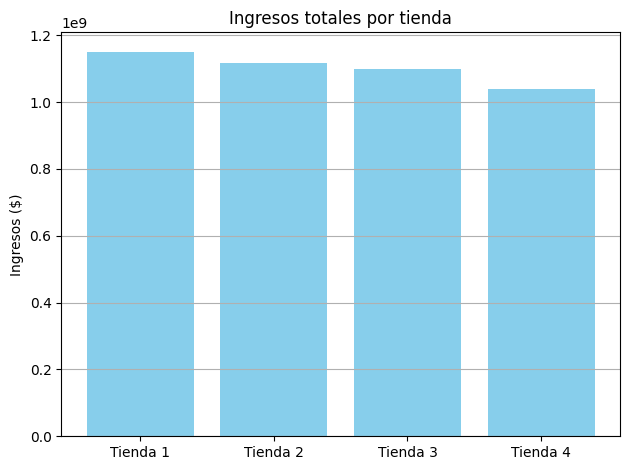

In [ ]:
plt.bar(ingresos_totales.keys(), ingresos_totales.values(), color='skyblue')
plt.title('Ingresos totales por tienda')
plt.ylabel('Ingresos ($)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

Mostrar las categorias que se repiten mas y las que se repiten menos por tienda

In [ ]:
ventas_por_categoria = {
    'Tienda 1': tienda['Categoría del Producto'].value_counts(),
    'Tienda 2': tienda2['Categoría del Producto'].value_counts(),
    'Tienda 3': tienda3['Categoría del Producto'].value_counts(),
    'Tienda 4': tienda4['Categoría del Producto'].value_counts()
}

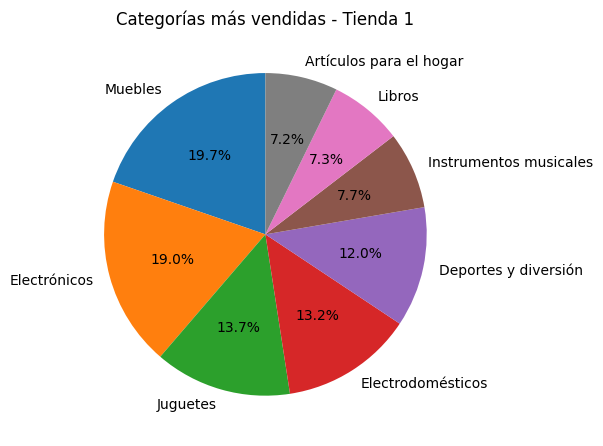

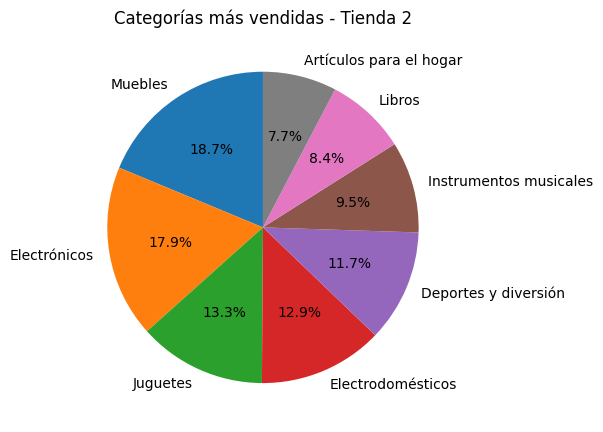

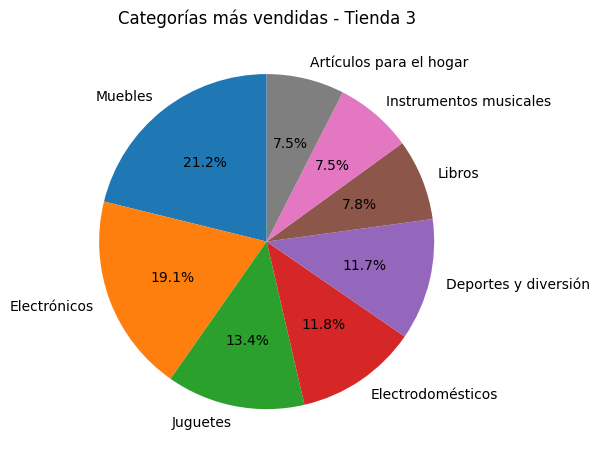

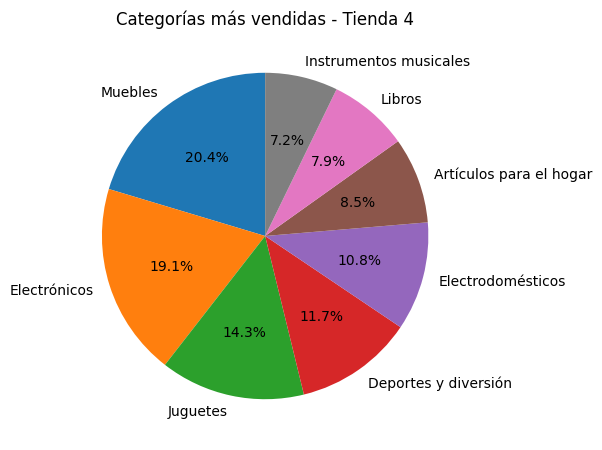

In [ ]:
for nombre, categorias in ventas_por_categoria.items():
    plt.figure(figsize=(6, 6))
    categorias.plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Categorías más vendidas - {nombre}')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# 3. Calificación promedio de la tienda


Mostrar calificacion promedio de cada tienda y hacer una grafica.

In [ ]:
calificacion_promedio = {
    'Tienda 1': tienda['Calificación'].mean(),
    'Tienda 2': tienda2['Calificación'].mean(),
    'Tienda 3': tienda3['Calificación'].mean(),
    'Tienda 4': tienda4['Calificación'].mean()
}
calificacion_redondeada = {tienda: round(valor, 2) for tienda, valor in calificacion_promedio.items()}

print(calificacion_redondeada)

{'Tienda 1': np.float64(3.98), 'Tienda 2': np.float64(4.04), 'Tienda 3': np.float64(4.05), 'Tienda 4': np.float64(4.0)}


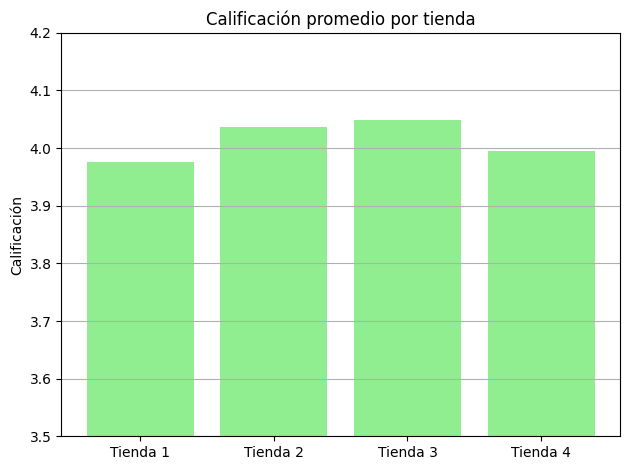

In [ ]:
plt.bar(calificacion_promedio.keys(), calificacion_promedio.values(), color='lightgreen')
plt.title('Calificación promedio por tienda')
plt.ylabel('Calificación')
plt.ylim(3.5, 4.2)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

Enlistar los articulos mas vendidos y graficar.

In [ ]:
productos_top5 = {
    'Tienda 1': tienda['Producto'].value_counts().head(5),
    'Tienda 2': tienda2['Producto'].value_counts().head(5),
    'Tienda 3': tienda3['Producto'].value_counts().head(5),
    'Tienda 4': tienda4['Producto'].value_counts().head(5),
}
productos_5menos = {
    'Tienda 1': tienda['Producto'].value_counts().tail(5),
    'Tienda 2': tienda2['Producto'].value_counts().tail(5),
    'Tienda 3': tienda3['Producto'].value_counts().tail(5),
    'Tienda 4': tienda4['Producto'].value_counts().tail(5),
}

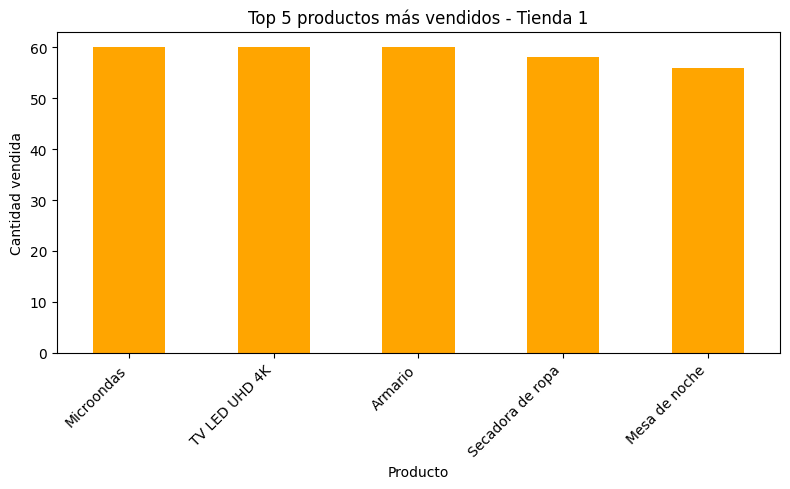

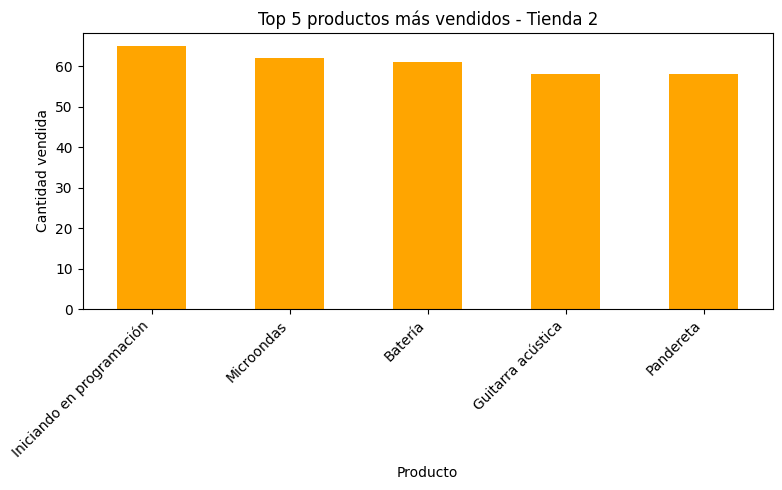

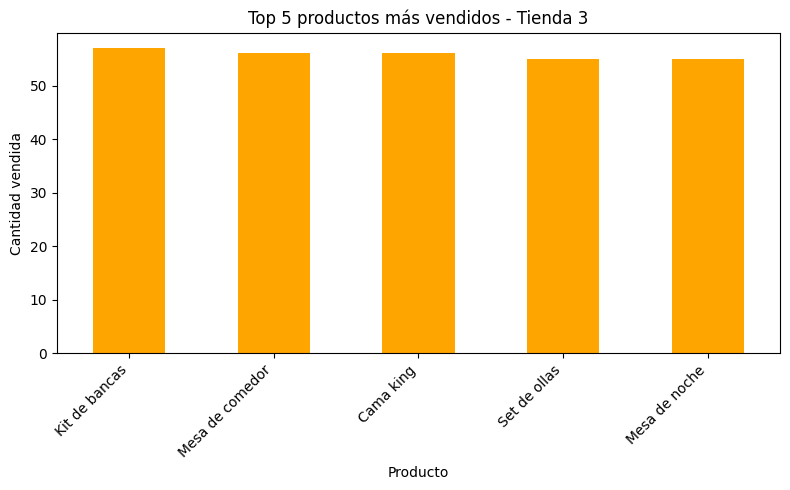

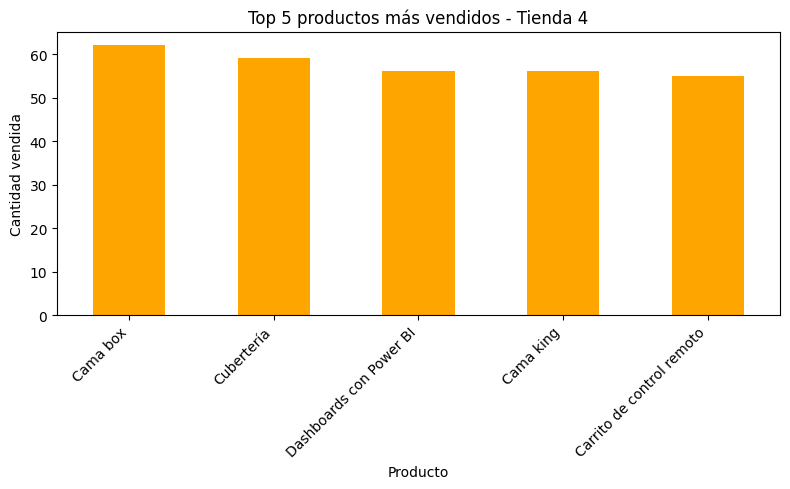

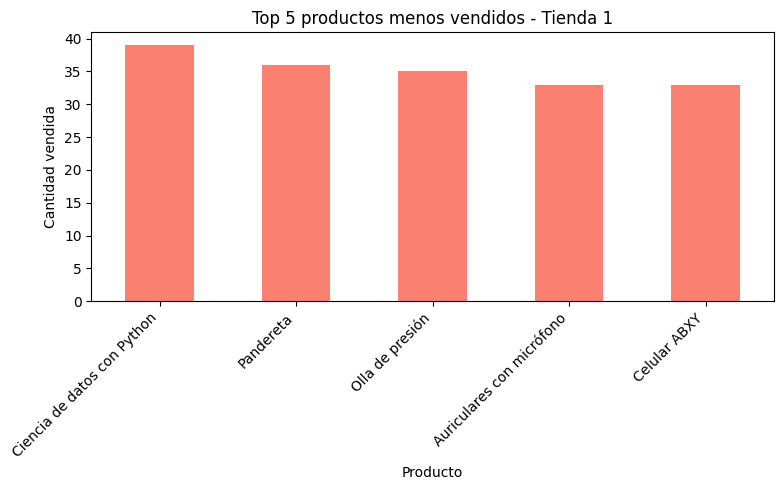

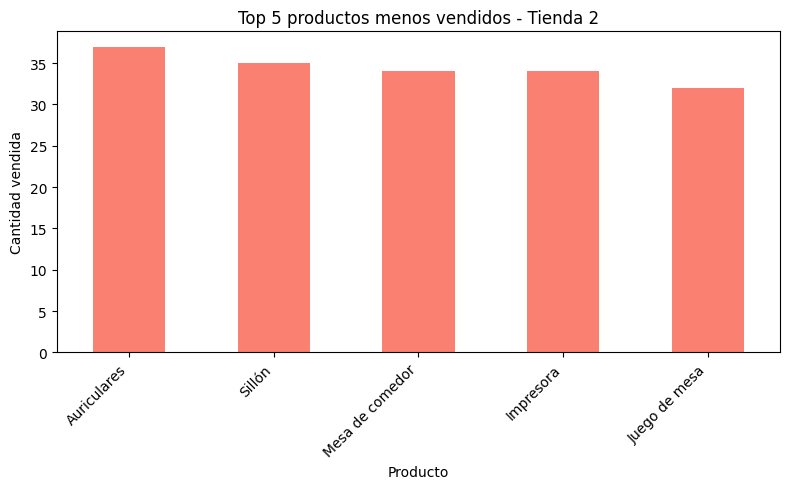

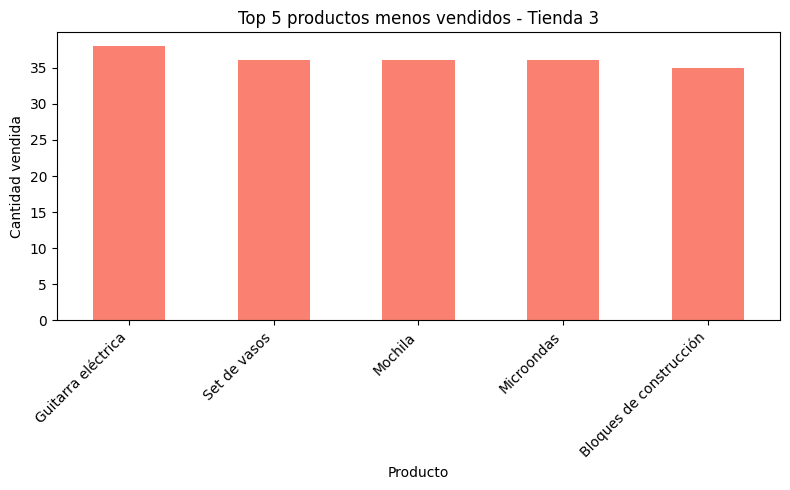

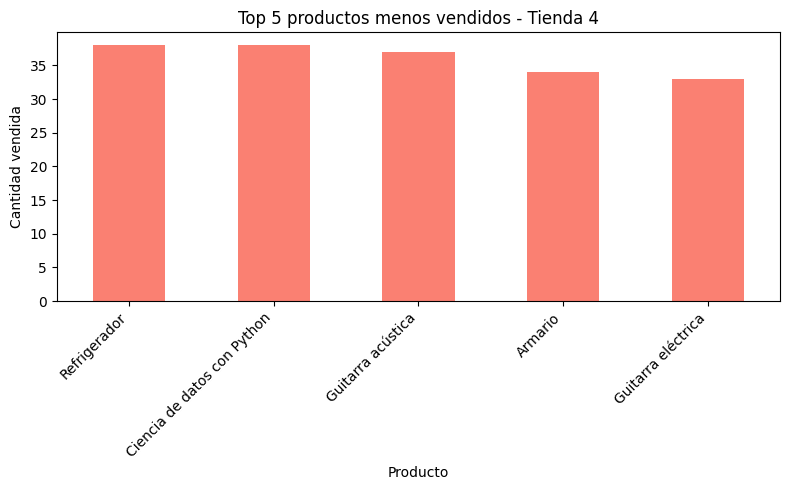

In [ ]:
for tienda, top5 in productos_top5.items():
    plt.figure(figsize=(8, 5))
    top5.plot(kind='bar', color='orange')
    plt.title(f'Top 5 productos más vendidos - {tienda}')
    plt.ylabel('Cantidad vendida')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


for tienda, bottom5 in productos_5menos.items():
    plt.figure(figsize=(8, 5))
    bottom5.plot(kind='bar', color='salmon')
    plt.title(f'Top 5 productos menos vendidos - {tienda}')
    plt.ylabel('Cantidad vendida')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 5. Envío promedio por tienda

Sumatoria del costo de envio por articulo

In [ ]:
envio_promedio = {
    'Tienda 1': tienda['Costo de envío'].mean(),
    'Tienda 2': tienda2['Costo de envío'].mean(),
    'Tienda 3': tienda3['Costo de envío'].mean(),
    'Tienda 4': tienda4['Costo de envío'].mean()
}
envio_redondeado = {tienda: round(valor, 2) for tienda, valor in envio_promedio.items()}

print(envio_redondeado)

{'Tienda 1': np.float64(26018.61), 'Tienda 2': np.float64(25216.24), 'Tienda 3': np.float64(24805.68), 'Tienda 4': np.float64(23459.46)}


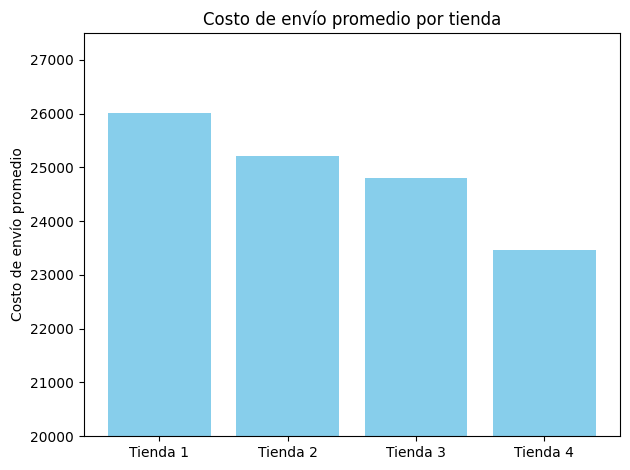

In [ ]:
plt.bar(envio_promedio.keys(), envio_promedio.values(), color='skyblue')
plt.ylabel('Costo de envío promedio')
plt.title('Costo de envío promedio por tienda')
plt.ylim(20000, 27500)
plt.tight_layout()
plt.show()

# 6. Analisis éxtras

In [ ]:
# Ingresos netos, restamos solo el costo de envio a la facturacion total por tienda, aunque me gustaria tener, gastos y costos para hacer un analisos mas preciso.
ingresos_netos = {
    tienda: ingresos_totales[tienda] - envio_promedio[tienda]
    for tienda in ingresos_totales
}
print(ingresos_netos)

{'Tienda 1': np.float64(1150854381.3904197), 'Tienda 2': np.float64(1116318283.764307), 'Tienda 3': np.float64(1097994794.319627), 'Tienda 4': np.float64(1038352240.5428329)}


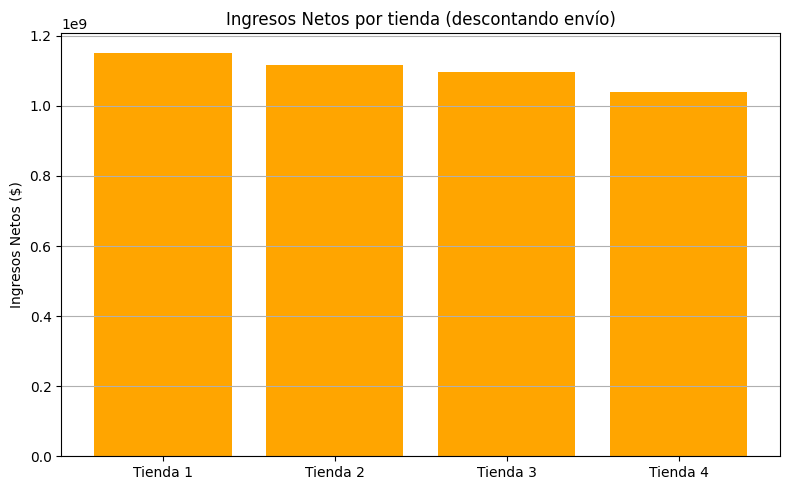

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(ingresos_netos.keys(), ingresos_netos.values(), color='orange')
plt.title('Ingresos Netos por tienda (descontando envío)')
plt.ylabel('Ingresos Netos ($)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
#Para buscar un patron de venta o ubicar temporadas fuertes de ventapor tienda.
for tienda in [tienda, tienda2, tienda3, tienda4]:
    tienda['Fecha de Compra'] = pd.to_datetime(tienda['Fecha de Compra'], dayfirst=True)

ventas_mensuales = {
    'Tienda 1': tienda.groupby(tienda['Fecha de Compra'].dt.to_period("M"))['Precio'].sum().to_timestamp(),
    'Tienda 2': tienda2.groupby(tienda2['Fecha de Compra'].dt.to_period("M"))['Precio'].sum().to_timestamp(),
    'Tienda 3': tienda3.groupby(tienda3['Fecha de Compra'].dt.to_period("M"))['Precio'].sum().to_timestamp(),
    'Tienda 4': tienda4.groupby(tienda4['Fecha de Compra'].dt.to_period("M"))['Precio'].sum().to_timestamp(),
}


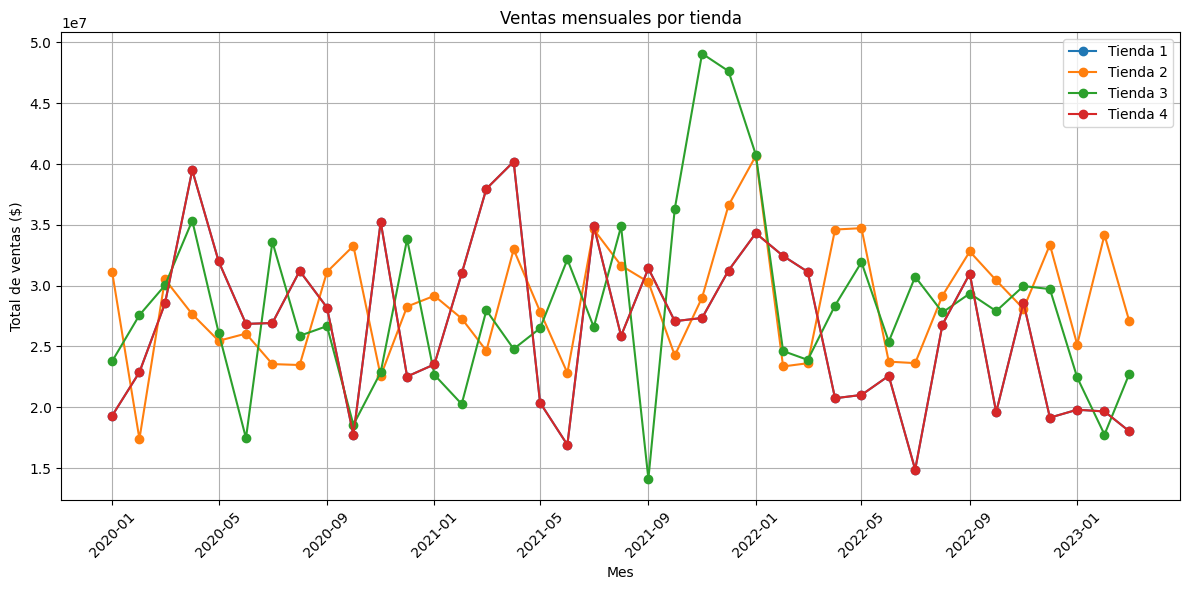

In [ ]:
plt.figure(figsize=(12, 6))
for tienda, datos in ventas_mensuales.items():
    plt.plot(datos.index, datos.values, marker='o', label=tienda)
plt.title('Ventas mensuales por tienda')
plt.xlabel('Mes')
plt.ylabel('Total de ventas ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Para saber la participación total de cada tienda en facturación.
total_ventas = {
    'Tienda 1': tienda['Precio'].sum(),
    'Tienda 2': tienda2['Precio'].sum(),
    'Tienda 3': tienda3['Precio'].sum(),
    'Tienda 4': tienda4['Precio'].sum()
}

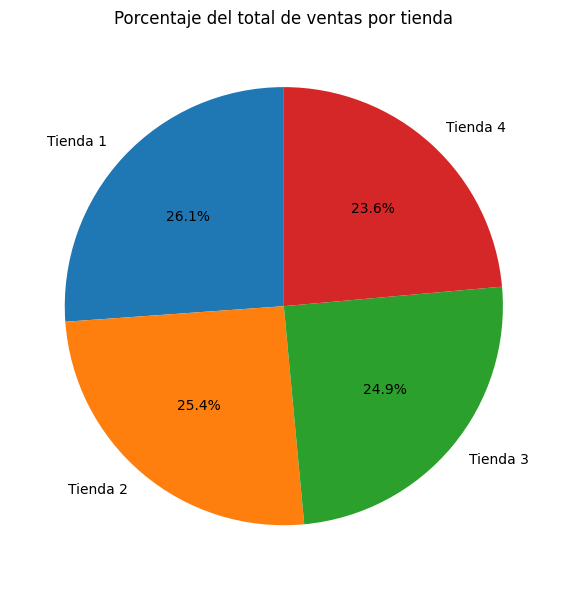

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(total_ventas.values(), labels=total_ventas.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Porcentaje del total de ventas por tienda')
plt.tight_layout()
plt.show()

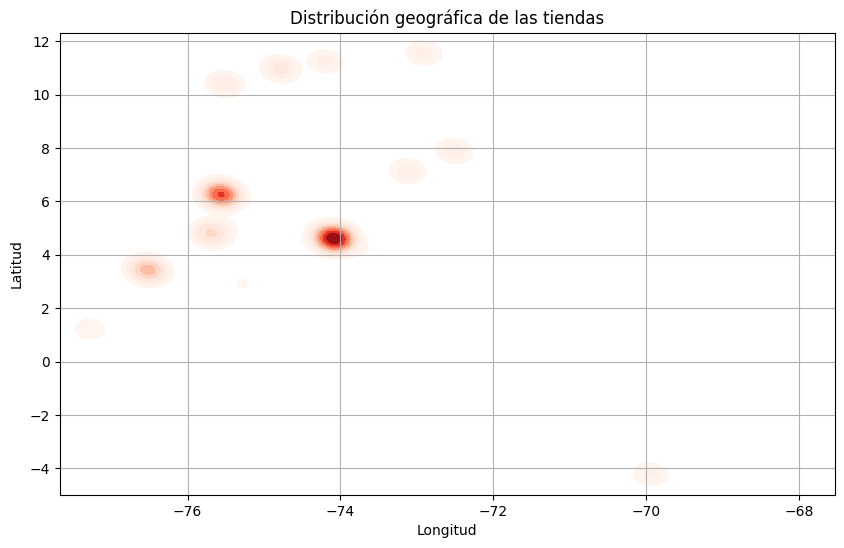

In [ ]:
#Para buscar las zonas Geograficas mas importantes de venta (yo no se hacer esto, es enteramente asistido por IA e investigación.)
!pip install seaborn
import seaborn as sns # Import the seaborn library and give it the alias 'sns'

all_tiendas = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)
plt.figure(figsize=(10, 6))
# Check if the column name is 'longitud' instead of 'Longitud'
sns.kdeplot(
    data=all_tiendas,
    x='lon',  # Changed 'Longitud' to 'longitud'
    y='lat',
    fill=True,
    cmap='Reds',
    bw_adjust=0.5,
    thresh=0.05
)
plt.title('Distribución geográfica de las tiendas')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.show()

In [ ]:
#Analisis de rendimiento de vendedores por tienda.
# Top 5 mejores vendedores por tienda
tienda = pd.read_csv(url)
top5_vendedores = {
    'Tienda 1': tienda['Vendedor'].value_counts().head(5),
    'Tienda 2': tienda2['Vendedor'].value_counts().head(5),
    'Tienda 3': tienda3['Vendedor'].value_counts().head(5),
    'Tienda 4': tienda4['Vendedor'].value_counts().head(5),
}

# Peores vendedores por tienda
bottom5_vendedores = {
    'Tienda 1': tienda['Vendedor'].value_counts().tail(5),
    'Tienda 2': tienda2['Vendedor'].value_counts().tail(5),
    'Tienda 3': tienda3['Vendedor'].value_counts().tail(5),
    'Tienda 4': tienda4['Vendedor'].value_counts().tail(5),
}
print(f'Top 5 mejores vendedores', top5_vendedores)
print(f'Bottom 5 peores vendedores', bottom5_vendedores)

Top 5 mejores vendedores {'Tienda 1': Vendedor
Izabela de León    197
Blanca Ramirez     180
Maria Alfonso      173
Rafael Acosta      171
Felipe Santos      170
Name: count, dtype: int64, 'Tienda 2': Vendedor
Izabela de León    195
Ángel Rodriguez    182
Juliana Costa      179
Pedro Gomez        171
Beatriz Morales    170
Name: count, dtype: int64, 'Tienda 3': Vendedor
Maria Alfonso      186
Juan Fernandez     184
Camila Rivera      173
Santiago Silva     171
Ángel Rodriguez    171
Name: count, dtype: int64, 'Tienda 4': Vendedor
Felipe Santos      196
Juan Fernandez     184
Mariana Herrera    183
Izabela de León    181
Santiago Silva     174
Name: count, dtype: int64}
Bottom 5 peores vendedores {'Tienda 1': Vendedor
Lucas Olivera      166
Beatriz Morales    165
Juan Fernandez     163
Mariana Herrera    156
Santiago Silva     144
Name: count, dtype: int64, 'Tienda 2': Vendedor
Juan Fernandez     163
Camila Rivera      161
Santiago Silva     161
Mariana Herrera    157
Rafael Acosta     

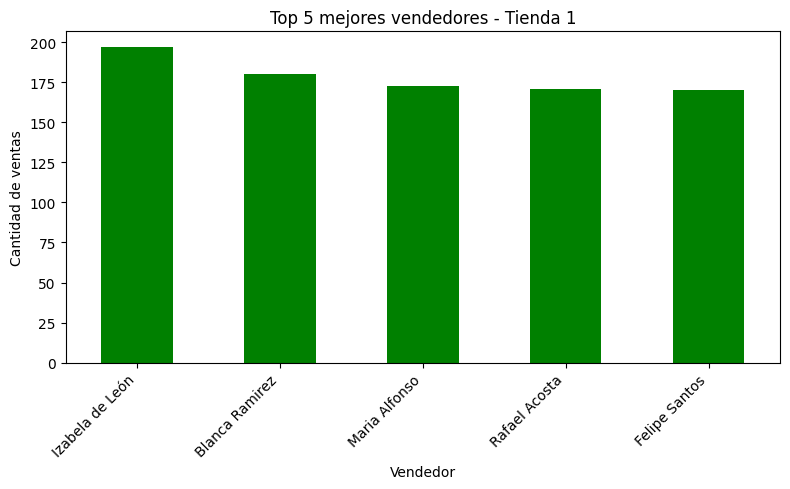

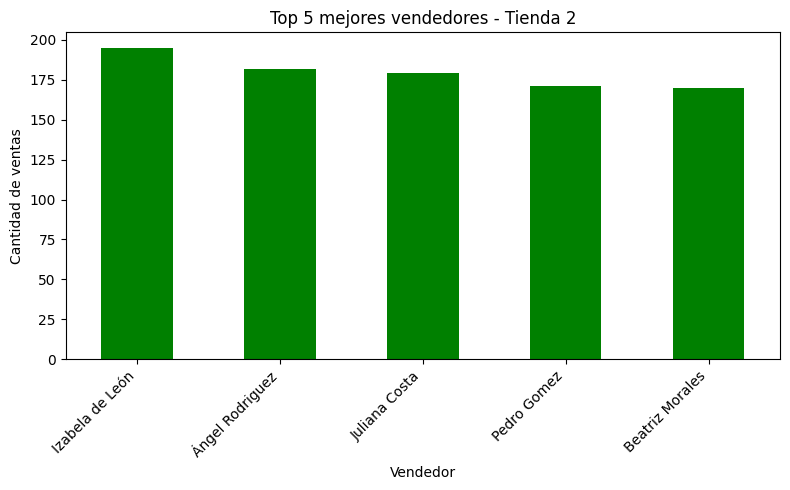

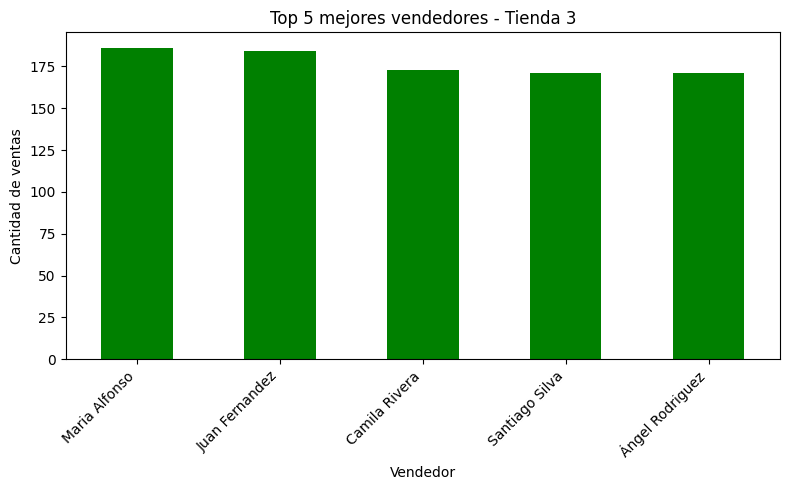

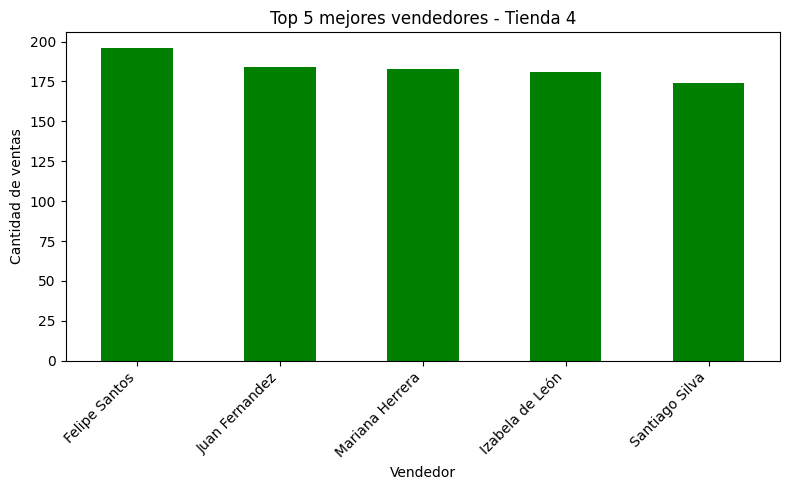

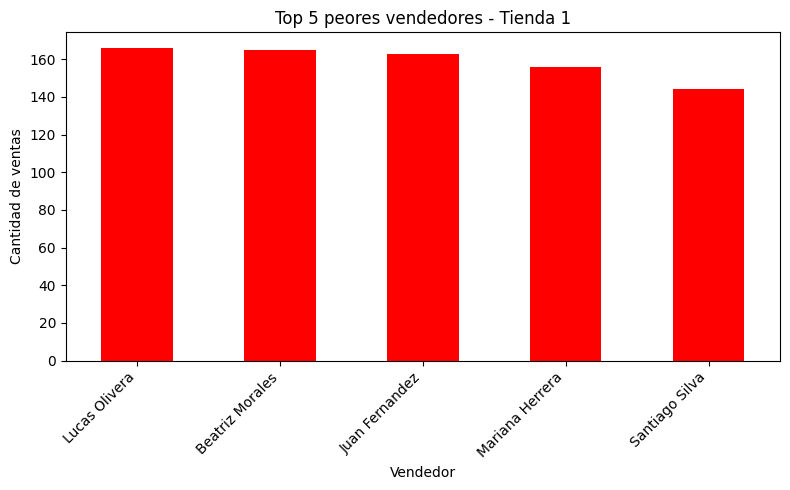

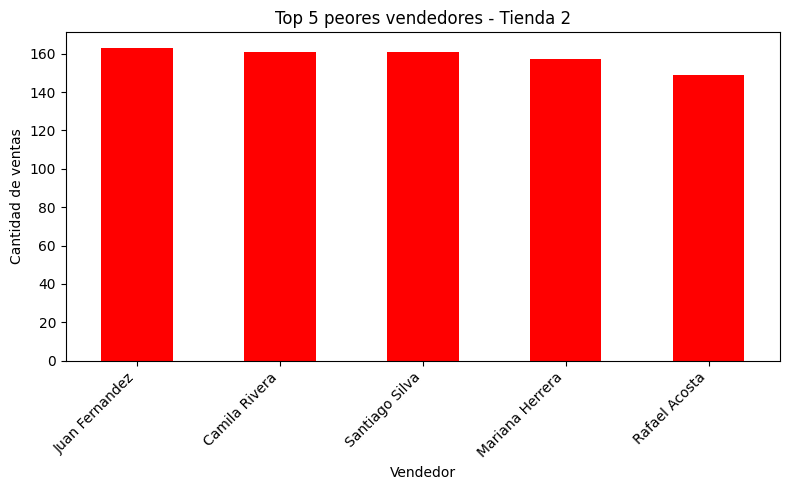

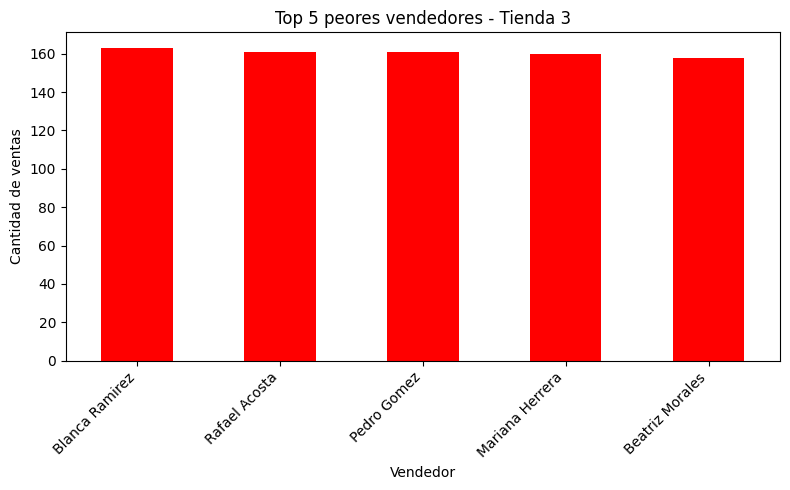

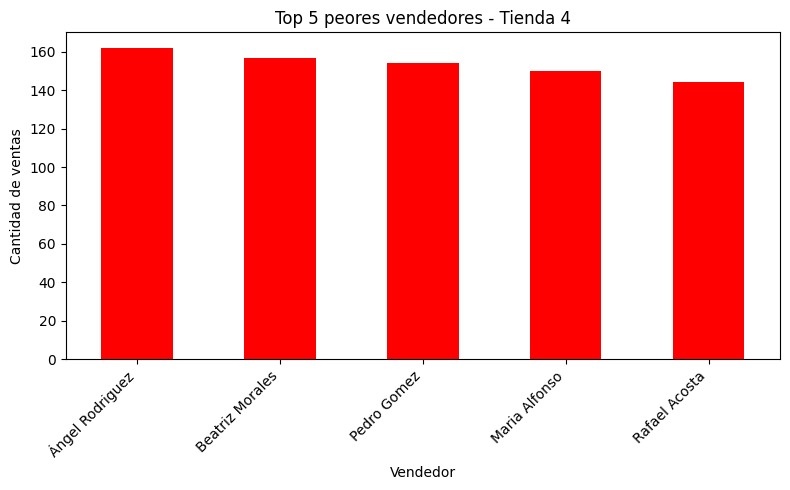

In [ ]:
for tienda, top5 in top5_vendedores.items():
  plt.figure(figsize=(8, 5))
  top5.plot(kind='bar', color='green')
  plt.title(f'Top 5 mejores vendedores - {tienda}')
  plt.ylabel('Cantidad de ventas')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

for tienda, bottom5 in bottom5_vendedores.items():
    plt.figure(figsize=(8, 5))
    bottom5.plot(kind='bar', color='red')
    plt.title(f'Top 5 peores vendedores - {tienda}')
    plt.ylabel('Cantidad de ventas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()